# Colitis Ulcerative
## Sick vs Healthy prediction

In [102]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

In [103]:
# Loading the data
otu = pd.read_csv(
    "C:\\Users\\bruge\\OneDrive - University of Copenhagen\\2. år\\4. Metagenomic Analysis of Microbiome\\group-project-group-5\\project\\data\\D003093_Colitis,_Ulcerative\\genus\\otu_table.xls",
    sep="\t"
)

metadata = pd.read_csv(
    "C:\\Users\\bruge\\OneDrive - University of Copenhagen\\2. år\\4. Metagenomic Analysis of Microbiome\\group-project-group-5\\project\\data\\D003093_Colitis,_Ulcerative\\genus\\sample_data.xls",
    sep="\t"
)

In [104]:
# Preparing the data
otu = otu.set_index(otu.columns[0])

# Transposing
X = otu.T

In [105]:
# print column names of metadata
print(metadata.columns)

print(metadata['Disease.name'].value_counts())
print(metadata['Disease.MESH.ID'].value_counts())

#D006262 = raske
#D003093 = UC

Index(['#SampleID', 'Project.ID', 'Experiment.type', 'Nr..reads.sequenced',
       'Country', 'Sex', 'Host.age', 'BMI', 'Recent.antibiotics.use',
       'Disease.MESH.ID', 'Disease.name', 'QC.status'],
      dtype='object')
Disease.name
1    1066
Name: count, dtype: int64
Disease.MESH.ID
D006262    615
D003093    451
Name: count, dtype: int64


In [106]:
metadata.head()

,#SampleID,Project.ID,Experiment.type,Nr..reads.sequenced,Country,Sex,Host.age,BMI,Recent.antibiotics.use,Disease.MESH.ID,Disease.name,QC.status
0,ERR209057,PRJEB1220,Metagenomics,7764468.0,Denmark,NaN,NaN,NaN,NaN,D006262,1,1
1,ERR209058,PRJEB1220,Metagenomics,4465624.0,Denmark,NaN,NaN,NaN,NaN,D006262,1,1
2,ERR209059,PRJEB1220,Metagenomics,9317812.0,Denmark,NaN,NaN,NaN,NaN,D006262,1,1
3,ERR209060,PRJEB1220,Metagenomics,9644824.0,Denmark,NaN,NaN,NaN,NaN,D006262,1,1
4,ERR209061,PRJEB1220,Metagenomics,9615221.0,Denmark,NaN,NaN,NaN,NaN,D006262,1,1


In [107]:
# Preparing column names
target_col = "Disease.MESH.ID"

metadata = metadata.set_index("#SampleID")

# Match metadata to OTU samples
metadata = metadata.loc[X.index]

y = metadata[target_col]

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [108]:
# count unique counts of Disease.MESH.ID in denmark, usa, spain (Country column)
print("Count of sick and healthy in Denmark:")
print(metadata[metadata['Country'] == 'Denmark']['Disease.MESH.ID'].value_counts())

print("Count of sick and healthy in USA:")
print(metadata[metadata['Country'] == 'United States of America']['Disease.MESH.ID'].value_counts())

print("Count of sick and healthy in Spain:")
print(metadata[metadata['Country'] == 'Spain']['Disease.MESH.ID'].value_counts())

Count of sick and healthy in Denmark:
Disease.MESH.ID
D006262    444
Name: count, dtype: int64
Count of sick and healthy in USA:
Disease.MESH.ID
D003093    138
D006262     55
Name: count, dtype: int64
Count of sick and healthy in Spain:
Disease.MESH.ID
D003093    223
D006262    116
Name: count, dtype: int64


In [109]:
metadata = metadata.dropna(subset=["Country"])

metadata = metadata[metadata["Country"] != "Denmark"]

print(metadata["Country"].value_counts())
print(metadata.shape)

Country
Spain                       339
United States of America    193
Name: count, dtype: int64
(532, 11)


In [110]:
# Data split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [111]:
# Prediction
y_pred = model.predict(X_test)

In [112]:
# Evaluate
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.81      0.86        91
           1       0.87      0.93      0.90       123

    accuracy                           0.88       214
   macro avg       0.89      0.87      0.88       214
weighted avg       0.88      0.88      0.88       214



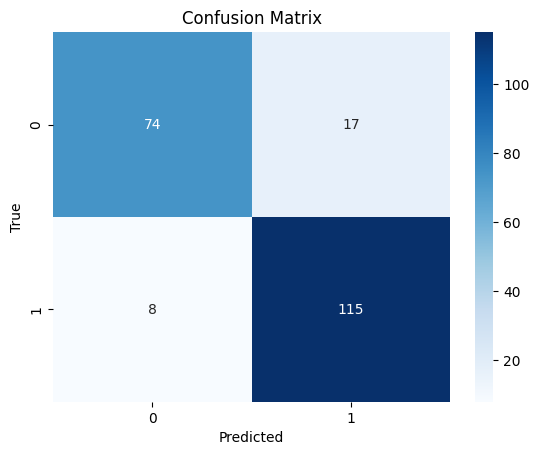

In [113]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()